## PC-Lab 4 - Predicting stock return using classic and more advanced models
### Henricus Bracht, Erdem Bayrakcioglu, Leonard Fischbach
### Executive Summary

**Approach.** We predict 5-, 20- and 60-day returns for eight stocks using OLS, Ridge, Random Forest and boosted trees. We preserve the 75%/25% chronological split and select features and settings using a separate validation period within training. We also add Lab 3 attention and test portfolios holding the four highest-ranked stocks.

**Findings.** The original six features beat the market/trend extensions on validation. On matched attention-covered rows, attention raises the 60-day OLS $R^2_{OOS}$ from **4.00% to 5.41%**, although it worsens validation performance at that horizon. Random Forest leads the test forecast comparison at 5 and 20 days; boosted trees lead at 60 days (**10.82%**). Direction accuracy needs caution: the tree results equal the always-positive benchmark.

Starting from $100, the validation-selected tree portfolios finish at **$154.65, $164.10 and $226.72** after the assignment's 1 bp fees for 5/20/60-day rebalancing. These are approximately the **55th, 66th and 96th percentiles** of random buy-and-hold allocations. OLS top-four portfolios earn more than the corresponding tree portfolios before costs at every horizon.

**Limitations.** Eight stocks, overlapping return windows, a single test period and idealized execution limit the conclusions. Attention coverage is incomplete; dividends and realistic trading frictions are not verified or modeled. Positive returns do not by themselves establish investment skill.

**Notebook structure.** Each section explains the approach and findings, followed by the code and selected outputs. All return targets are in percentage points; portfolio returns are compounded from price ratios.


## Imports and Load Data

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import statsmodels.api as sm

RANDOM_SEED = 42
RIDGE_ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]
INITIAL_WEALTH = 100.0
FEE_RATE = 0.0001  # 1 basis point = 0.01%
N_RANDOM_PORTFOLIOS = 1000
LAB_DIR = Path.cwd() if (Path.cwd() / 'Data_PCLab4_Stock_Price.csv').exists() else Path.cwd() / '#4'


#### Create modified base-dataframes: Normalized values (100 in 2012), relative returns etc. 

In [2]:
price_df = pd.read_csv(LAB_DIR / 'Data_PCLab4_Stock_Price.csv')
vol_df = pd.read_csv(LAB_DIR / 'Data_PCLab4_Stock_Volume.csv')

# Validate date order and alignment before constructing any returns.
for frame in (price_df, vol_df):
    frame["Date"] = pd.to_datetime(frame["Date"])
    frame.sort_values("Date", inplace=True, ignore_index=True)
    assert frame["Date"].is_unique
    assert frame.drop(columns="Date").notna().all().all()
    assert (frame.drop(columns="Date") > 0).all().all()
assert price_df["Date"].equals(vol_df["Date"])

price_norm_df = price_df.copy()
for col in price_norm_df.columns[1:]:
    price_norm_df[col] = (
        price_norm_df[col] / price_norm_df[col].iloc[0] * 100
    )

vol_norm_df = vol_df.copy()
for col in vol_norm_df.columns[1:]:
    vol_norm_df[col] = (
        vol_norm_df[col] / vol_norm_df[col].iloc[0] * 100
    )

daily_returns_df = price_df.copy()
stocks = [col for col in price_df.columns if col != "Date"]
daily_returns_df[stocks] = price_df[stocks].pct_change() * 100

vol_change_df = vol_df.copy()
stocks = [col for col in vol_df.columns if col != "Date"]
vol_change_df[stocks] = vol_df[stocks].pct_change() * 100

vol_change_df["Date"] = pd.to_datetime(vol_change_df["Date"])
daily_returns_df["Date"] = pd.to_datetime(daily_returns_df["Date"])
vol_df["Date"] = pd.to_datetime(vol_df["Date"])
price_df["Date"] = pd.to_datetime(price_df["Date"])
price_norm_df["Date"] = pd.to_datetime(price_norm_df["Date"])
vol_norm_df["Date"] = pd.to_datetime(vol_df["Date"])

dfs = {
    "Price": price_df,
    "Volume": vol_df,
    "Normalized Price": price_norm_df,
    "Normalized Volume": vol_norm_df,
    "Daily Returns": daily_returns_df,
    "Daily Volume Change": vol_change_df
}

for name, df in dfs.items():
    print(name)
    display(df.head())


Price


,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,60.198570,75.510002,30.120001,12.13,175.929993,180.550003,28.250000,313.644379,1295.500000
1,2012-01-13,59.972858,74.599998,30.070000,12.35,178.419998,179.160004,22.790001,311.328064,1289.089966
2,2012-01-17,60.671429,75.239998,30.250000,12.25,181.660004,180.000000,26.600000,313.116364,1293.670044
3,2012-01-18,61.301430,75.059998,30.330000,12.73,189.440002,181.070007,26.809999,315.273285,1308.040039
4,2012-01-19,61.107143,75.559998,30.420000,12.80,194.449997,180.520004,26.760000,318.590851,1314.500000


Volume


,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,53146800,3934500,26511100,17891100,5385800,6881000,729300,3764400,4019890000
1,2012-01-13,56505400,4641100,22096800,16621800,4753500,5279200,5500400,4631800,3692370000
2,2012-01-17,60724300,3700100,23500200,15480800,5644500,6003400,4651600,3832800,4010490000
3,2012-01-18,69197800,4189500,22015000,18387600,7473500,4600600,1260200,5544000,4096160000
4,2012-01-19,65434600,5397300,25524000,14022900,7096000,8567200,1246300,12657800,4465890000


Normalized Price


...

,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1,2012-01-13,106.319477,117.959080,83.349239,92.905411,88.259869,76.721407,754.202660,123.042185,91.852513
2,2012-01-17,114.257679,94.042445,88.642870,86.527938,104.803372,87.246040,637.817085,101.817023,99.766163
3,2012-01-18,130.201254,106.481128,83.040689,102.775123,138.763044,66.859468,172.795832,147.274466,101.897316
4,2012-01-19,123.120489,137.178803,96.276654,78.379194,131.753871,124.505159,170.889894,336.250133,111.094831


Daily Returns


,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-13,-0.374946,-1.205144,-0.166006,1.813685,1.415339,-0.769869,-19.327430,-0.738516,-0.494792
2,2012-01-17,1.164812,0.857909,0.598603,-0.809717,1.815943,0.468852,16.717854,0.574410,0.355295
3,2012-01-18,1.038382,-0.239234,0.264463,3.918367,4.282725,0.594448,0.789470,0.688856,1.110793
4,2012-01-19,-0.316937,0.666134,0.296736,0.549882,2.644634,-0.303752,-0.186494,1.052283,0.493866


Daily Volume Change


,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-13,6.319477,17.959080,-16.650761,-7.094589,-11.740131,-23.278593,654.202660,23.042185,-8.147487
2,2012-01-17,7.466366,-20.275366,6.351146,-6.864479,18.744083,13.717988,-15.431605,-17.250313,8.615605
3,2012-01-18,13.954051,13.226670,-6.319946,18.776807,32.403224,-23.366759,-72.908247,44.646212,2.136148
4,2012-01-19,-5.438323,28.829216,15.939132,-23.737192,-5.051181,86.219189,-1.103000,128.315296,9.026259


We load the .csv's into pandas dataframes. We create a normalized versions in order to be able to compare and plot absolute values of the stocks.  
We also compute one table with daily returns.

## Task 1 - Basic Manipulation and Descriptive Statistics

### Major Findings:

- Trading volume stays rather stable for most stocks, except for **TSLA**, where it increased drastically around 2014.  

- Based on visual inspection, there appears to be substantial variation in daily stock returns.
- **Returns vary substantially across stocks:** TSLA (4,765%) and AMZN (1,651%) achieved the highest total returns, while IBM had a negative total return (-29.8%).
- **Higher returns generally came with higher risk:** TSLA had the highest average daily return (0.239%) but also the highest annualized volatility (54.5%), compared with only 16.7% for the S&P 500.
- **AAPL stands out for trading activity:** AAPL had the highest average trading volume among the individual stocks (58M shares per day), considerably above the overall average of 15M.
- **Daily returns have a low signal-to-noise ratio:** Average daily returns are very small relative to their standard deviations. Across stocks, the average daily return is 0.089% compared with a daily standard deviation of 2.165%, highlighting the difficulty of predicting daily returns.
- **Positive days are only slightly more frequent than negative days:** Individual stocks generated positive returns on roughly 51–54% of trading days, suggesting that simply predicting a positive return every day would already provide a directional-accuracy benchmark slightly above 50%.
- **Extreme daily movements are economically significant:** Individual-stock daily returns range from approximately -33.6% to +33.1%. Differences in skewness also indicate asymmetric return distributions and substantial tail observations.
- **Overall, the large differences in performance, volatility, trading activity, and return distributions across securities motivate testing whether price and volume information can help predict future returns.**
- **Missing correlation between daily return and daily change in trading volume:** Correlation differs per stock but is in general close to 0 and has different signs depending on the stocks. 

### 1.1 Stock Price Development

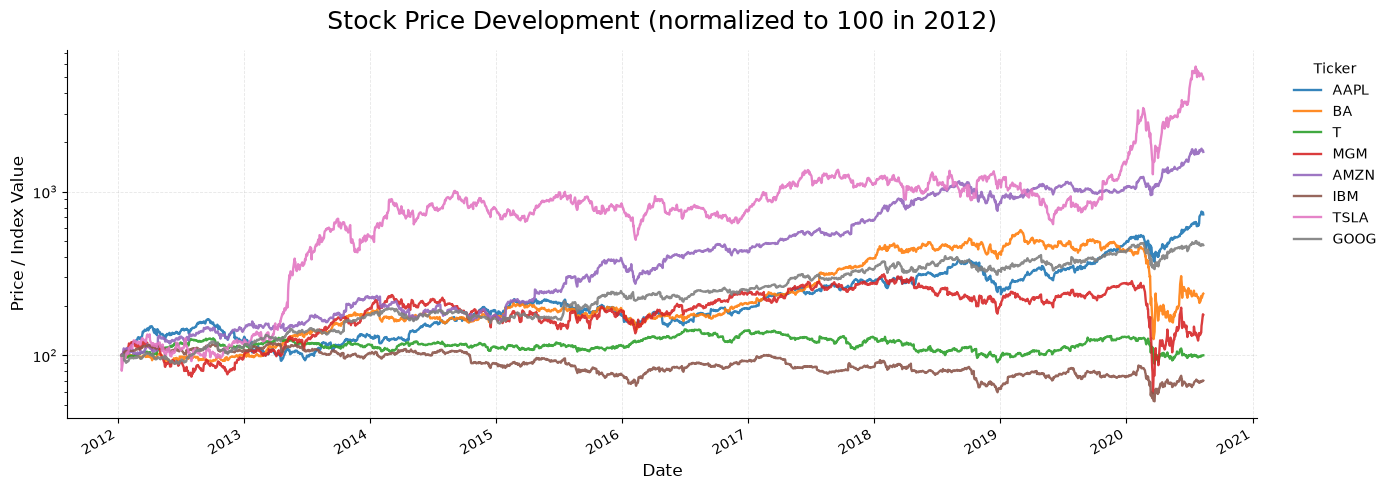

In [3]:
# Everything except Date and S&P
stocks = [col for col in price_norm_df.columns
          if col not in ["Date", "sp500"]]

# 1. STOCK PRICE PLOT
fig, ax = plt.subplots(figsize=(14, 5))

colors = plt.cm.tab10.colors

for i, stock in enumerate(stocks):
    ax.plot(
        price_norm_df["Date"],
        price_norm_df[stock],
        label=stock,
        color=colors[i % len(colors)],
        linewidth=1.7,
        alpha=0.9)

ax.set_title(
    "Stock Price Development (normalized to 100 in 2012)",
    fontsize=18,
    pad=15)

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price / Index Value", fontsize=12)
ax.set_yscale("log")
# Nice date ticks
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.3)

ax.legend(
    title="Ticker",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 1.2 Volume Development (raw and normalized)

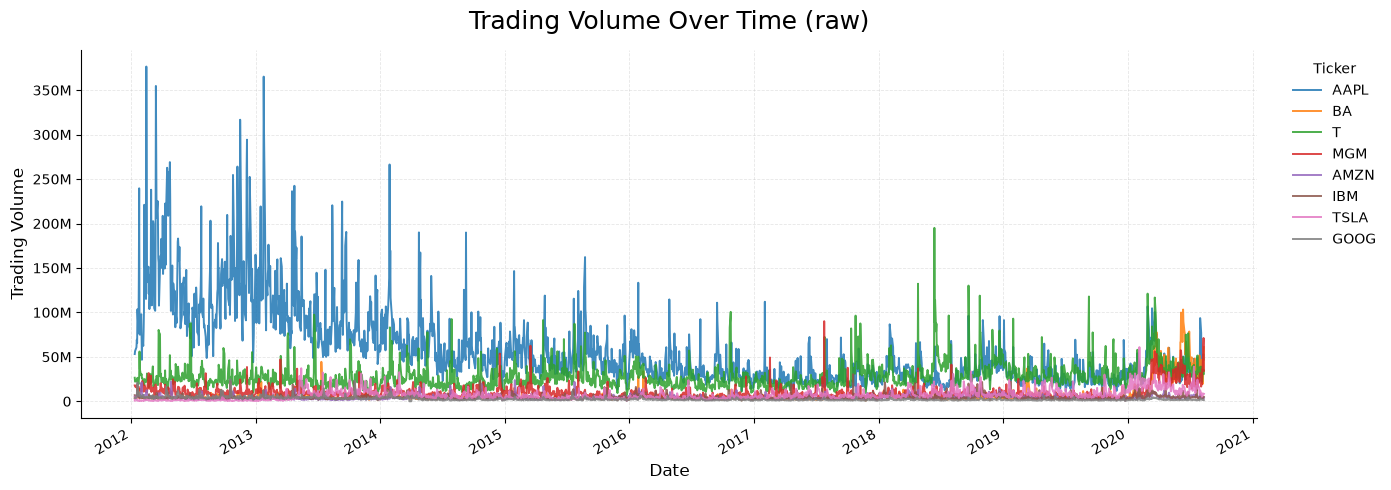

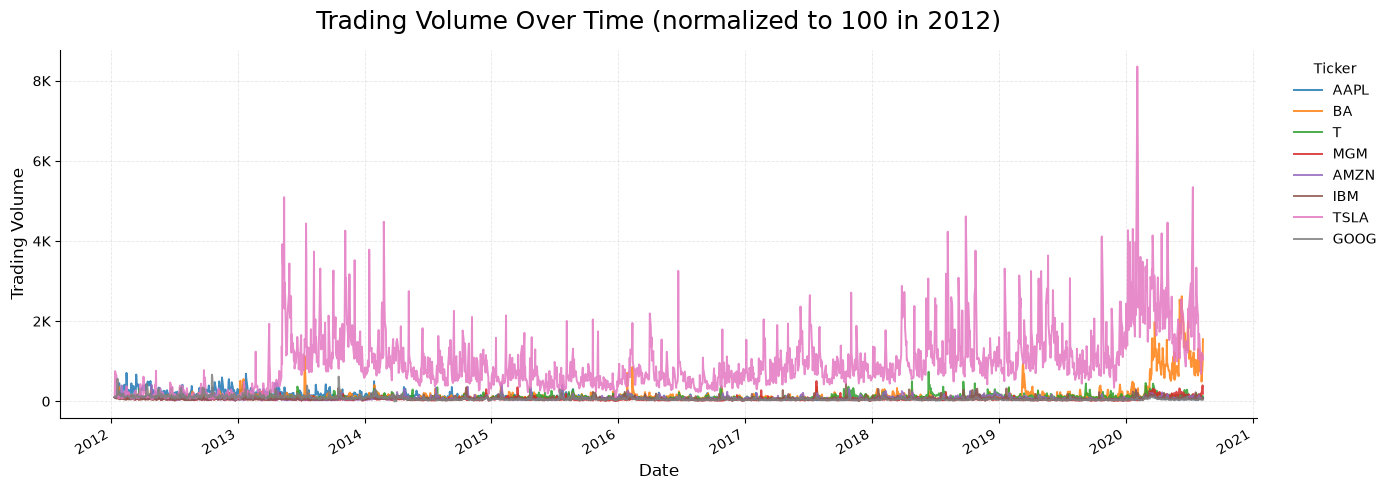

In [4]:
# TRADING VOLUME PLOT - RAW
fig, ax = plt.subplots(figsize=(14, 5))

for i, stock in enumerate(stocks):
    ax.plot(
        vol_df["Date"],
        vol_df[stock],
        label=stock,
        color=colors[i % len(colors)],
        linewidth=1.4,
        alpha=0.85)

ax.set_title(
    "Trading Volume Over Time (raw)",
    fontsize=18,
    pad=15
)

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Trading Volume", fontsize=12)
#ax.set_yscale('log')

# Date formatting
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Display 50,000,000 as 50M etc.
def millions(x, pos):
    if abs(x) >= 1_000_000_000:
        return f"{x / 1_000_000_000:.1f}B"
    elif abs(x) >= 1_000_000:
        return f"{x / 1_000_000:.0f}M"
    elif abs(x) >= 1_000:
        return f"{x / 1_000:.0f}K"
    return f"{x:.0f}"

ax.yaxis.set_major_formatter(FuncFormatter(millions))

ax.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.3
)

ax.legend(
    title="Ticker",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# TRADING VOLUME PLOT - NORMALIZED
fig, ax = plt.subplots(figsize=(14, 5))

for i, stock in enumerate(stocks):
    ax.plot(
        vol_norm_df["Date"],
        vol_norm_df[stock],
        label=stock,
        color=colors[i % len(colors)],
        linewidth=1.4,
        alpha=0.85)

ax.set_title(
    "Trading Volume Over Time (normalized to 100 in 2012)",
    fontsize=18,
    pad=15
)

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Trading Volume", fontsize=12)
#ax.set_yscale('log')

# Date formatting
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Display 50,000,000 as 50M etc.
def millions(x, pos):
    if abs(x) >= 1_000_000_000:
        return f"{x / 1_000_000_000:.1f}B"
    elif abs(x) >= 1_000_000:
        return f"{x / 1_000_000:.0f}M"
    elif abs(x) >= 1_000:
        return f"{x / 1_000:.0f}K"
    return f"{x:.0f}"

ax.yaxis.set_major_formatter(FuncFormatter(millions))

ax.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.3
)

ax.legend(
    title="Ticker",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()



### 1.3 Daily returns

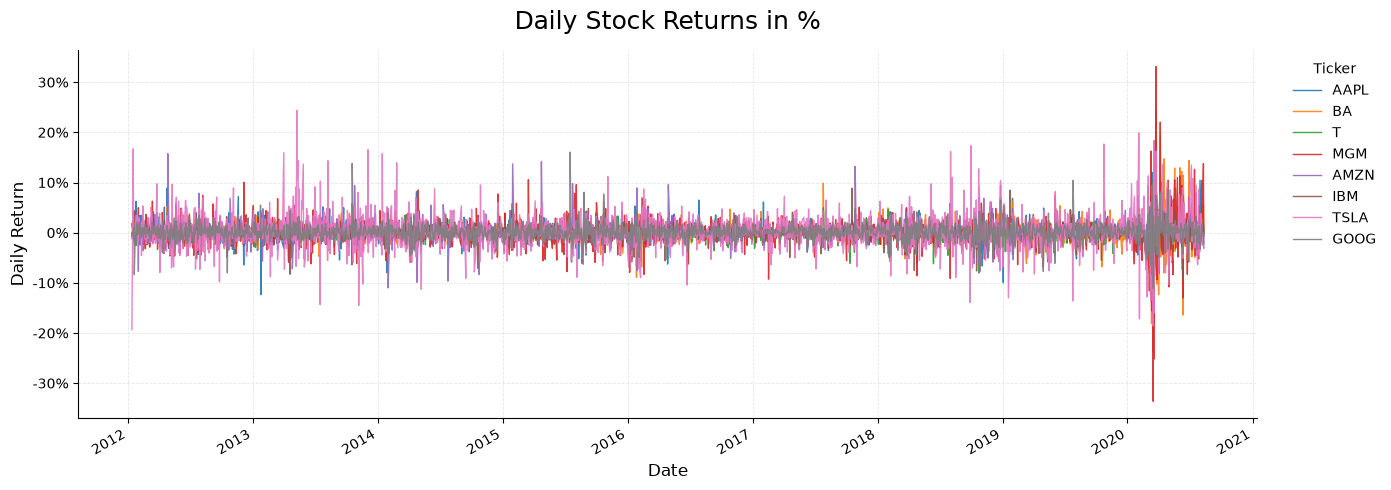

In [5]:
# 1. STOCK PRICE PLOT
fig, ax = plt.subplots(figsize=(14, 5))

colors = plt.cm.tab10.colors

for i, stock in enumerate(stocks):
    ax.plot(
        daily_returns_df["Date"],
        daily_returns_df[stock],
        label=stock,
        color=colors[i % len(colors)],
        linewidth=1.0,
        alpha=0.9)

ax.set_title(
    "Daily Stock Returns in %",
    fontsize=18,
    pad=15)

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Daily Return", fontsize=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.0f}%"))
# Nice date ticks
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.3)

ax.legend(
    title="Ticker",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 1.4 Summary statistics

In [6]:
summary_rows = []

for stock in stocks:

    returns = daily_returns_df[stock].dropna()
    volume = vol_df[stock].dropna()
    prices = price_df[stock].dropna()

    # Total return over the full sample
    total_return = (prices.iloc[-1] / prices.iloc[0] - 1) * 100

    summary_rows.append({
        "Security": stock,

        # Volume statistics
        "Avg Volume": volume.mean(),
        "Median Volume": volume.median(),
        "Max Volume": volume.max(),
        "Std Volume": volume.std(),

        # Return statistics
        "Avg Daily Return (%)": returns.mean(),
        "Median Daily Return (%)": returns.median(),
        "Std Daily Return (%)": returns.std(),
        "Annualized Volatility (%)": returns.std() * np.sqrt(252),
        "Min Daily Return (%)": returns.min(),
        "Max Daily Return (%)": returns.max(),

        "Positive Days (%)": (returns > 0).mean() * 100,
        "Skewness": returns.skew(),

        # Full-period performance
        "Total Return (%)": total_return
    })

summary_stats = pd.DataFrame(summary_rows).set_index("Security")


#Construct Overall Statistics:
individual_stocks = [s for s in stocks if s != "sp500"]

# Pool all stock-day observations
all_returns = daily_returns_df[individual_stocks].stack().dropna()
all_volumes = vol_df[individual_stocks].stack().dropna()

# Equal-weight buy-and-hold portfolio:
# normalize each stock to 1 at the beginning, then average across stocks
normalized_prices = (
    price_df[individual_stocks]
    / price_df[individual_stocks].iloc[0]
)

equal_weight_portfolio = normalized_prices.mean(axis=1)

overall_total_return = (
    equal_weight_portfolio.iloc[-1]
    / equal_weight_portfolio.iloc[0]
    - 1
) * 100

overall_row = pd.DataFrame({
    "Avg Volume": [all_volumes.mean()],
    "Median Volume": [all_volumes.median()],
    "Max Volume": [all_volumes.max()],
    "Std Volume": [all_volumes.std()],
    "Avg Daily Return (%)": [all_returns.mean()],
    "Median Daily Return (%)": [all_returns.median()],
    "Std Daily Return (%)": [all_returns.std()],
    "Annualized Volatility (%)": [all_returns.std() * np.sqrt(252)],
    "Min Daily Return (%)": [all_returns.min()],
    "Max Daily Return (%)": [all_returns.max()],
    "Positive Days (%)": [(all_returns > 0).mean() * 100],
    "Skewness": [all_returns.skew()], 
    "Total Return (%)": [overall_total_return]
}, index=["Overall (excl. S&P500)"])

summary_stats = pd.concat([summary_stats, overall_row])

In [7]:
summary_display = summary_stats.copy()

volume_cols = [
    "Avg Volume",
    "Median Volume",
    "Max Volume",
    "Std Volume"
]

# Convert volume to millions
summary_display[volume_cols] = summary_display[volume_cols] / 1_000_000

summary_display = summary_display.rename(columns={
    "Avg Volume": "Avg Volume (M)",
    "Median Volume": "Median Volume (M)",
    "Max Volume": "Max Volume (M)",
    "Std Volume": "Std Volume (M)"
})

summary_display.style.format({
    "Avg Volume (M)": "{:,.2f}",
    "Median Volume (M)": "{:,.2f}",
    "Max Volume (M)": "{:,.2f}",
    "Std Volume (M)": "{:,.2f}",
    "Avg Daily Return (%)": "{:.3f}%",
    "Median Daily Return (%)": "{:.3f}%",
    "Std Daily Return (%)": "{:.3f}%",
    "Annualized Volatility (%)": "{:.2f}%",
    "Min Daily Return (%)": "{:.2f}%",
    "Max Daily Return (%)": "{:.2f}%",
    "Total Return (%)": "{:.2f}%"
}).set_caption(
    "Summary Statistics: Stock Returns and Trading Volume"
)

,Avg Volume (M),Median Volume (M),Max Volume (M),Std Volume (M),Avg Daily Return (%),Median Daily Return (%),Std Daily Return (%),Annualized Volatility (%),Min Daily Return (%),Max Daily Return (%),Positive Days (%),Skewness,Total Return (%)
AAPL,58.20,42.09,376.53,45.68,0.108%,0.083%,1.776%,28.20%,-12.86%,11.98%,52.594995,-0.097865,626.76%
BA,6.42,3.99,103.21,9.71,0.066%,0.078%,2.260%,35.88%,-23.85%,24.32%,52.224282,0.227336,138.55%
T,28.32,24.86,195.08,14.29,0.008%,0.060%,1.265%,20.08%,-9.24%,10.02%,52.363299,-0.497455,0.27%
MGM,9.85,7.90,90.10,7.30,0.065%,0.112%,2.747%,43.61%,-33.61%,33.11%,51.899907,0.007458,77.25%
AMZN,4.10,3.49,23.86,2.29,0.151%,0.117%,1.928%,30.61%,-11.00%,15.75%,53.938832,0.620135,1651.08%
IBM,4.45,3.83,30.49,2.46,-0.006%,0.022%,1.431%,22.72%,-12.85%,11.30%,50.880445,-0.464064,-29.80%
TSLA,7.00,5.58,60.94,5.78,0.239%,0.117%,3.431%,54.46%,-19.33%,24.40%,51.621872,0.488056,4765.10%
GOOG,2.50,1.81,24.98,1.93,0.084%,0.061%,1.586%,25.18%,-11.10%,16.05%,52.594995,0.634918,371.97%
Overall (excl. S&P500),15.11,5.37,376.53,25.20,0.089%,0.075%,2.165%,34.37%,-33.61%,33.11%,52.264829,0.378525,950.15%


### 1.5 Correlation between change in price and change in volume

In [8]:
correlations = pd.DataFrame({
    "Return-Volume Correlation": [
        daily_returns_df[stock].corr(vol_change_df[stock])
        for stock in stocks
    ]
}, index=stocks)

# Add the overall correlation
all_returns = daily_returns_df[stocks].stack()
all_vol_changes = vol_change_df[stocks].stack()
overall_corr = all_returns.corr(all_vol_changes)
correlations.loc['Overall'] = overall_corr

correlations

,Return-Volume Correlation
AAPL,-0.114204
BA,-0.071670
T,-0.139598
MGM,0.025558
AMZN,0.070281
IBM,-0.081546
TSLA,0.045621
GOOG,-0.024028
Overall,-0.012541


## Task 2 - Train and Test samples + Ridge regression

### Major Findings:
- **Predictive power is limited but positive relative to the zero-return benchmark:** OLS achieves positive $R^2_{OOS}$ at all three horizons (0.54%, 0.69%, and 1.85% for 5, 20, and 60 days), with predictive performance increasing with the forecast horizon.  

- **Ridge regularization provides almost no improvement over OLS:** with $\alpha=1$, Ridge produces nearly identical results across all horizons, suggesting that regularization adds little value with the current six-feature specification.
- **Standard test $R^2$ and $R^2_{OOS}$ lead to different conclusions:** the 20- and 60-day models have negative conventional test $R^2$, but positive $R^2_{OOS}$ because the latter evaluates performance relative to a zero-return forecast rather than the test-sample mean.
- **Direction accuracy needs a benchmark:** the original models achieve roughly 55–57%, below the always-positive rates of 56.26%, 58.08% and 58.57% for 5/20/60 days.
- **The extensions give a mixed picture:** validation retains the original features at all horizons, and explicit tuning selects Ridge penalties of 100, 100 and 1. Lab 3 attention modestly improves test forecasts on matched samples, but its 60-day validation result is worse. Sections 2.6–2.8 show these checks.


### 2.1 Build the feature dataframe for OLS and Ridge

#### Approach
- The eight individual stocks are combined into a single panel dataset, while the S&P 500 is excluded from the baseline specification.  

- For each stock-date observation, six predictors are constructed: past **5-, 20-, and 60-trading-day returns** and corresponding **5-, 20-, and 60-day changes in trading volume**.
- Three continuous target variables are constructed separately: the realized stock return over the subsequent **5, 20, and 60 trading days**.

#### Findings
- The resulting datasets contain **16,752**, **16,632**, and **16,312** observations for the 5-, 20-, and 60-day prediction horizons, respectively.  

- Using the same six predictors across all horizons allows differences in model performance to be attributed to the **forecast horizon rather than a changing feature set**.

In [9]:
# 1. Individual stocks only

model_stocks = [
    col for col in price_df.columns
    if col not in ["Date", "sp500"]
]

# 2. Convert price and volume data to long format

price_long = price_df.melt(
    id_vars="Date",
    value_vars=model_stocks,
    var_name="Stock",
    value_name="Price"
)

volume_long = vol_df.melt(
    id_vars="Date",
    value_vars=model_stocks,
    var_name="Stock",
    value_name="Volume"
)

panel_df = pd.merge(
    price_long,
    volume_long,
    on=["Date", "Stock"],
    how="inner"
)

panel_df = panel_df.sort_values(
    ["Stock", "Date"]
).reset_index(drop=True)


# 3. Create all 6 predictor variables

grouped = panel_df.groupby("Stock")

lookback_windows = [5, 20, 60]

for h in lookback_windows:

    # Past cumulative stock return over h trading days
    panel_df[f"Past_Return_{h}d"] = (
        panel_df["Price"] / grouped["Price"].shift(h) - 1
    ) * 100

    # Past percentage change in trading volume over h trading days
    panel_df[f"Past_Volume_Change_{h}d"] = (
        panel_df["Volume"] / grouped["Volume"].shift(h) - 1
    ) * 100


# 4. Create the 3 future return targets

forecast_horizons = [5, 20, 60]

for h in forecast_horizons:

    panel_df[f"Future_Return_{h}d"] = (
        grouped["Price"].shift(-h) / panel_df["Price"] - 1
    ) * 100

    # Date at which the future return period ends
    panel_df[f"Target_Date_{h}d"] = grouped["Date"].shift(-h)


# 5. Feature list

feature_cols = [
    "Past_Return_5d",
    "Past_Return_20d",
    "Past_Return_60d",
    "Past_Volume_Change_5d",
    "Past_Volume_Change_20d",
    "Past_Volume_Change_60d"
]


# 6. Build one dataframe per forecast horizon

model_dfs = {}

for h in forecast_horizons:

    target_col = f"Future_Return_{h}d"
    target_date_col = f"Target_Date_{h}d"

    df = panel_df[
        ["Date", "Stock"]
        + feature_cols
        + [target_col, target_date_col]
    ].dropna().copy()

    model_dfs[h] = df

    print(f"\n{h}-day prediction dataframe:")
    display(df.head())
    print(f"Observations: {len(df):,}")


5-day prediction dataframe:


,Date,Stock,Past_Return_5d,Past_Return_20d,Past_Return_60d,Past_Volume_Change_5d,Past_Volume_Change_20d,Past_Volume_Change_60d,Future_Return_5d,Target_Date_5d
60,2012-04-10,AAPL,1.585761,13.847833,49.135013,48.696051,118.454124,318.522470,-2.981992,2012-04-17
61,2012-04-11,AAPL,-0.495767,10.227076,49.162720,-16.529053,0.833691,208.207180,-2.852125,2012-04-18
62,2012-04-12,AAPL,-0.246673,5.629426,46.637621,7.217694,-56.701597,152.920495,-5.673041,2012-04-19
63,2012-04-13,AAPL,-4.489647,3.359175,41.043082,34.047635,-25.874670,210.575192,-5.328550,2012-04-20
64,2012-04-16,AAPL,-8.817562,-0.929004,35.623616,75.853069,27.292863,301.464516,-1.453130,2012-04-23


Observations: 16,752

20-day prediction dataframe:


,Date,Stock,Past_Return_5d,Past_Return_20d,Past_Return_60d,Past_Volume_Change_5d,Past_Volume_Change_20d,Past_Volume_Change_60d,Future_Return_20d,Target_Date_20d
60,2012-04-10,AAPL,1.585761,13.847833,49.135013,48.696051,118.454124,318.522470,-9.588826,2012-05-08
61,2012-04-11,AAPL,-0.495767,10.227076,49.162720,-16.529053,0.833691,208.207180,-9.105716,2012-05-09
62,2012-04-12,AAPL,-0.246673,5.629426,46.637621,7.217694,-56.701597,152.920495,-8.389937,2012-05-10
63,2012-04-13,AAPL,-4.489647,3.359175,41.043082,34.047635,-25.874670,210.575192,-6.364519,2012-05-11
64,2012-04-16,AAPL,-8.817562,-0.929004,35.623616,75.853069,27.292863,301.464516,-3.776746,2012-05-14


Observations: 16,632

60-day prediction dataframe:


,Date,Stock,Past_Return_5d,Past_Return_20d,Past_Return_60d,Past_Volume_Change_5d,Past_Volume_Change_20d,Past_Volume_Change_60d,Future_Return_60d,Target_Date_60d
60,2012-04-10,AAPL,1.585761,13.847833,49.135013,48.696051,118.454124,318.522470,-2.943800,2012-07-05
61,2012-04-11,AAPL,-0.495767,10.227076,49.162720,-16.529053,0.833691,208.207180,-3.244976,2012-07-06
62,2012-04-12,AAPL,-0.246673,5.629426,46.637621,7.217694,-56.701597,152.920495,-1.425886,2012-07-09
63,2012-04-13,AAPL,-4.489647,3.359175,41.043082,34.047635,-25.874670,210.575192,0.492381,2012-07-10
64,2012-04-16,AAPL,-8.817562,-0.929004,35.623616,75.853069,27.292863,301.464516,4.188715,2012-07-11


Observations: 16,312


### 2.2 Train-Test Split

#### Approach
- The data are split **chronologically** rather than randomly: approximately 75% of dates are used for training and the remaining 25% for out-of-sample testing. 

- To avoid look-ahead bias, training observations are only retained if their entire future-return window ends before the test period begins.
- The six predictors are transformed using a **MinMaxScaler fitted exclusively on the training sample** and subsequently applied to the test sample.

In [10]:
# Chronological 75% / 25% split

all_dates = np.sort(panel_df["Date"].unique())

split_index = int(len(all_dates) * 0.75)
split_date = pd.Timestamp(all_dates[split_index])

print(f"Train/Test cutoff date: {split_date.date()}")


X_train_scaled = {}
X_test_scaled = {}

y_train = {}
y_test = {}

train_data = {}
test_data = {}

scalers = {}


for h in forecast_horizons:

    df = model_dfs[h].copy()

    target_col = f"Future_Return_{h}d"
    target_date_col = f"Target_Date_{h}d"

    # Prevent future-return window from crossing into test period
    train_df = df[
        df[target_date_col] < split_date
    ].copy()

    test_df = df[
        df["Date"] >= split_date
    ].copy()

    train_data[h] = train_df
    test_data[h] = test_df

    # Fit MinMaxScaler on training features only
    scaler = MinMaxScaler(feature_range=(0, 1))

    X_train_scaled[h] = pd.DataFrame(
        scaler.fit_transform(train_df[feature_cols]),
        columns=feature_cols,
        index=train_df.index
    )

    X_test_scaled[h] = pd.DataFrame(
        scaler.transform(test_df[feature_cols]),
        columns=feature_cols,
        index=test_df.index
    )

    y_train[h] = train_df[target_col]
    y_test[h] = test_df[target_col]

    scalers[h] = scaler

    print(f"\n{h}-day horizon:")
    print(f"Training observations: {len(train_df):,}")
    print(f"Testing observations:  {len(test_df):,}")
    print(
        f"Train period: {train_df['Date'].min().date()} "
        f"to {train_df['Date'].max().date()}"
    )
    print(
        f"Test period:  {test_df['Date'].min().date()} "
        f"to {test_df['Date'].max().date()}"
    )


def r2_oos(y_true, y_pred):
    return 1 - (
        np.sum((np.asarray(y_true) - np.asarray(y_pred)) ** 2)
        / np.sum(np.asarray(y_true) ** 2)
    )

Train/Test cutoff date: 2018-06-20

5-day horizon:
Training observations: 12,432
Testing observations:  4,280
Train period: 2012-04-10 to 2018-06-12
Test period:  2018-06-20 to 2020-08-04

20-day horizon:
Training observations: 12,312
Testing observations:  4,160
Train period: 2012-04-10 to 2018-05-21
Test period:  2018-06-20 to 2020-07-14

60-day horizon:
Training observations: 11,992
Testing observations:  3,840
Train period: 2012-04-10 to 2018-03-23
Test period:  2018-06-20 to 2020-05-15


### 2.3 OLS models (5-, 20- and 60-day ahead)

#### Approach
- Three pooled OLS models are estimated separately for **5-, 20-, and 60-day future returns**, using the same six lagged return and volume-change predictors.  

- Performance is evaluated using conventional test $R^2$, MSE, and the $R^2_{OOS}$ measure of Gu et al. (2020), which benchmarks predictions against a **zero-return forecast**.

#### Findings
- OLS produces positive $R^2_{OOS}$ at every horizon: **0.54% (5d), 0.69% (20d), and 1.85% (60d)**, indicating modest predictive improvement over forecasting zero returns.  

- Conventional test $R^2$ is **0.08% for 5 days but -1.04% and -1.36% for 20 and 60 days**, showing that beating the zero-return benchmark does not necessarily imply beating the test-sample mean benchmark.
- The **60-day model has the highest $R^2_{OOS}$** among the original OLS models. However, the training-mean forecast beats OLS at 20 and 60 days (section 2.6), so this alone is weak evidence that the features add predictive information.


#### 2.3.1 OLS MODEL: 5-DAY RETURN

In [11]:
h = 5

# statsmodels requires us to add the intercept manually
X_train_ols_5 = sm.add_constant(
    X_train_scaled[h],
    has_constant="add"
)

X_test_ols_5 = sm.add_constant(
    X_test_scaled[h],
    has_constant="add"
)

# Fit OLS on training sample
ols_5 = sm.OLS(
    y_train[h],
    X_train_ols_5
).fit()

# Out-of-sample predictions
pred_ols_5 = ols_5.predict(X_test_ols_5)

# Evaluation
roos_ols_5 = r2_oos(y_test[h], pred_ols_5)
r2_test_ols_5 = r2_score(y_test[h], pred_ols_5)
mse_ols_5 = mean_squared_error(y_test[h], pred_ols_5)

print("OLS — 5-Day Return Prediction")
print("=" * 45)
print(f"In-sample R²:       {ols_5.rsquared:.4f}")
print(f"Out-of-sample R²:   {r2_test_ols_5:.4f}")
print(f"R²_OOS (Gu et al.): {roos_ols_5:.4f}")
print(f"Test MSE:            {mse_ols_5:.4f}")

display(ols_5.summary())

OLS — 5-Day Return Prediction
In-sample R²:       0.0041
Out-of-sample R²:   0.0008
R²_OOS (Gu et al.): 0.0054
Test MSE:            50.6749


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Future_Return_5d   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     8.532
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           2.84e-09
Time:                        09:38:52   Log-Likelihood:                -34921.
No. Observations:               12432   AIC:                         6.986e+04
Df Residuals:                   12425   BIC:                         6.991e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.9742      0.233      4.183      0.000       0.518       1.431
Past_Return_5d            -4.2857      0.796     -5.387      0.000      -5.845      -2.726
Past_Return_20d            2.4337      0.799      3.046      0.002       0.868       4.000
Past_Return_60d            1.6062      0.655      2.450      0.014       0.321       2.891
Past_Volume_Change_5d     -3.3630      2.304     -1.460      0.144      -7.879       1.153
Past_Volume_Change_20d    -0.0223      2.592     -0.009      0.993      -5.103       5.058
Past_Volume_Change_60d     6.2169      2.694      2.307      0.021       0.935      11.498
==============================================================================
Omnibus:                     3128.043   Durbin-Watson:                   0.390
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            47477.280
Skew:                           0.795   Prob(JB):                         0.00
Kurtosis:                      12.441   Cond. No.                         82.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### 2.3.2 OLS MODEL: 20-DAY RETURN

In [12]:
h = 20

X_train_ols_20 = sm.add_constant(
    X_train_scaled[h],
    has_constant="add"
)

X_test_ols_20 = sm.add_constant(
    X_test_scaled[h],
    has_constant="add"
)

ols_20 = sm.OLS(
    y_train[h],
    X_train_ols_20
).fit()

pred_ols_20 = ols_20.predict(X_test_ols_20)

roos_ols_20 = r2_oos(y_test[h], pred_ols_20)
r2_test_ols_20 = r2_score(y_test[h], pred_ols_20)
mse_ols_20 = mean_squared_error(y_test[h], pred_ols_20)

print("OLS — 20-Day Return Prediction")
print("=" * 45)
print(f"In-sample R²:       {ols_20.rsquared:.4f}")
print(f"Out-of-sample R²:   {r2_test_ols_20:.4f}")
print(f"R²_OOS (Gu et al.): {roos_ols_20:.4f}")
print(f"Test MSE:            {mse_ols_20:.4f}")

display(ols_20.summary())

OLS — 20-Day Return Prediction
In-sample R²:       0.0075
Out-of-sample R²:   -0.0104
R²_OOS (Gu et al.): 0.0069
Test MSE:            197.0950


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Future_Return_20d   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     15.55
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           7.37e-18
Time:                        09:38:52   Log-Likelihood:                -43383.
No. Observations:               12312   AIC:                         8.678e+04
Df Residuals:                   12305   BIC:                         8.683e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0.1931      0.477     -0.405      0.686      -1.129       0.743
Past_Return_5d            -1.9658      1.632     -1.205      0.228      -5.164       1.233
Past_Return_20d            6.9047      1.637      4.218      0.000       3.696      10.114
Past_Return_60d            4.6823      1.344      3.483      0.000       2.047       7.317
Past_Volume_Change_5d     -7.5864      4.708     -1.611      0.107     -16.815       1.643
Past_Volume_Change_20d    11.0522      5.298      2.086      0.037       0.668      21.436
Past_Volume_Change_60d    19.3587      5.508      3.515      0.000       8.562      30.155
==============================================================================
Omnibus:                     6032.535   Durbin-Watson:                   0.107
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           139002.840
Skew:                           1.841   Prob(JB):                         0.00
Kurtosis:                      19.044   Cond. No.                         81.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### 2.3.3 OLS MODEL: 60-DAY RETURN

In [13]:
h = 60

X_train_ols_60 = sm.add_constant(
    X_train_scaled[h],
    has_constant="add"
)

X_test_ols_60 = sm.add_constant(
    X_test_scaled[h],
    has_constant="add"
)

ols_60 = sm.OLS(
    y_train[h],
    X_train_ols_60
).fit()

pred_ols_60 = ols_60.predict(X_test_ols_60)

roos_ols_60 = r2_oos(y_test[h], pred_ols_60)
r2_test_ols_60 = r2_score(y_test[h], pred_ols_60)
mse_ols_60 = mean_squared_error(y_test[h], pred_ols_60)

print("OLS — 60-Day Return Prediction")
print("=" * 45)
print(f"In-sample R²:       {ols_60.rsquared:.4f}")
print(f"Out-of-sample R²:   {r2_test_ols_60:.4f}")
print(f"R²_OOS (Gu et al.): {roos_ols_60:.4f}")
print(f"Test MSE:            {mse_ols_60:.4f}")

display(ols_60.summary())

OLS — 60-Day Return Prediction
In-sample R²:       0.0220
Out-of-sample R²:   -0.0136
R²_OOS (Gu et al.): 0.0185
Test MSE:            672.2766


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Future_Return_60d   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     45.00
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           9.30e-55
Time:                        09:38:52   Log-Likelihood:                -50847.
No. Observations:               11992   AIC:                         1.017e+05
Df Residuals:                   11985   BIC:                         1.018e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0.1058      0.994     -0.106      0.915      -2.055       1.843
Past_Return_5d             1.1411      3.408      0.335      0.738      -5.539       7.822
Past_Return_20d           -2.2328      3.396     -0.657      0.511      -8.890       4.424
Past_Return_60d           34.5891      2.770     12.489      0.000      29.160      40.018
Past_Volume_Change_5d      5.3958      9.640      0.560      0.576     -13.500      24.292
Past_Volume_Change_20d    27.8804     10.851      2.569      0.010       6.611      49.150
Past_Volume_Change_60d    60.2069     11.287      5.334      0.000      38.082      82.332
==============================================================================
Omnibus:                    10652.626   Durbin-Watson:                   0.037
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           648059.820
Skew:                           4.029   Prob(JB):                         0.00
Kurtosis:                      38.100   Cond. No.                         80.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 2.4 Ridge models (5-, 20- and 60-day ahead)

#### Approach
- The same three forecasting problems are re-estimated using **Ridge regression with $\alpha=1$**, introducing an $L_2$ penalty that shrinks coefficients toward zero.  

- Because all predictors are MinMax-scaled, Ridge is applied to comparably scaled features; its out-of-sample performance can therefore be directly compared with the corresponding OLS models.
- Here we retain the original $\alpha=1$ benchmark. Section 2.7 explicitly compares penalties using chronological validation.

#### Findings
- Ridge produces $R^2_{OOS}$ values of **0.53% (5d), 0.67% (20d), and 1.72% (60d)**, which are extremely close to—but slightly below—the corresponding OLS results.  

- With the current six predictors and $\alpha=1$, coefficient shrinkage therefore provides **no meaningful out-of-sample improvement**, suggesting that overfitting from the linear feature set is currently limited.
- The similarity between OLS and Ridge motivates testing whether improvements require **additional predictors or nonlinear relationships**, rather than regularization alone.


#### 2.4.1 RIDGE: 5-DAY RETURN

In [14]:
h = 5
alpha = 1.0

ridge_5 = Ridge(alpha=alpha)

ridge_5.fit(
    X_train_scaled[h],
    y_train[h]
)

pred_ridge_5 = ridge_5.predict(
    X_test_scaled[h]
)

roos_ridge_5 = r2_oos(y_test[h], pred_ridge_5)
r2_train_ridge_5 = ridge_5.score(
    X_train_scaled[h],
    y_train[h]
)
r2_test_ridge_5 = r2_score(
    y_test[h],
    pred_ridge_5
)
mse_ridge_5 = mean_squared_error(
    y_test[h],
    pred_ridge_5
)

print("Ridge — 5-Day Return Prediction")
print("=" * 45)
print(f"Penalty α:           {alpha}")
print(f"In-sample R²:       {r2_train_ridge_5:.4f}")
print(f"Out-of-sample R²:   {r2_test_ridge_5:.4f}")
print(f"R²_OOS (Gu et al.): {roos_ridge_5:.4f}")
print(f"Test MSE:            {mse_ridge_5:.4f}")

ridge_coef_5 = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": ridge_5.coef_
})

display(ridge_coef_5)

Ridge — 5-Day Return Prediction
Penalty α:           1.0
In-sample R²:       0.0040
Out-of-sample R²:   0.0008
R²_OOS (Gu et al.): 0.0053
Test MSE:            50.6785


,Feature,Coefficient
0,Past_Return_5d,-4.081462
1,Past_Return_20d,2.309363
2,Past_Return_60d,1.624128
3,Past_Volume_Change_5d,-2.512351
4,Past_Volume_Change_20d,0.019456
5,Past_Volume_Change_60d,4.278971


#### 2.4.2 RIDGE: 20-DAY RETURN

In [15]:
h = 20
alpha = 1.0

ridge_20 = Ridge(alpha=alpha)

ridge_20.fit(
    X_train_scaled[h],
    y_train[h]
)

pred_ridge_20 = ridge_20.predict(
    X_test_scaled[h]
)

roos_ridge_20 = r2_oos(y_test[h], pred_ridge_20)
r2_train_ridge_20 = ridge_20.score(
    X_train_scaled[h],
    y_train[h]
)
r2_test_ridge_20 = r2_score(
    y_test[h],
    pred_ridge_20
)
mse_ridge_20 = mean_squared_error(
    y_test[h],
    pred_ridge_20
)

print("Ridge — 20-Day Return Prediction")
print("=" * 45)
print(f"Penalty α:           {alpha}")
print(f"In-sample R²:       {r2_train_ridge_20:.4f}")
print(f"Out-of-sample R²:   {r2_test_ridge_20:.4f}")
print(f"R²_OOS (Gu et al.): {roos_ridge_20:.4f}")
print(f"Test MSE:            {mse_ridge_20:.4f}")

ridge_coef_20 = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": ridge_20.coef_
})

display(ridge_coef_20)

Ridge — 20-Day Return Prediction
Penalty α:           1.0
In-sample R²:       0.0074
Out-of-sample R²:   -0.0107
R²_OOS (Gu et al.): 0.0067
Test MSE:            197.1411


,Feature,Coefficient
0,Past_Return_5d,-1.763282
1,Past_Return_20d,6.702309
2,Past_Return_60d,4.740523
3,Past_Volume_Change_5d,-5.614022
4,Past_Volume_Change_20d,7.925390
5,Past_Volume_Change_60d,13.429049


#### 2.4.3 RIDGE: 60-DAY RETURN

In [16]:
h = 60
alpha = 1.0

ridge_60 = Ridge(alpha=alpha)

ridge_60.fit(
    X_train_scaled[h],
    y_train[h]
)

pred_ridge_60 = ridge_60.predict(
    X_test_scaled[h]
)

roos_ridge_60 = r2_oos(y_test[h], pred_ridge_60)
r2_train_ridge_60 = ridge_60.score(
    X_train_scaled[h],
    y_train[h]
)
r2_test_ridge_60 = r2_score(
    y_test[h],
    pred_ridge_60
)
mse_ridge_60 = mean_squared_error(
    y_test[h],
    pred_ridge_60
)

print("Ridge — 60-Day Return Prediction")
print("=" * 45)
print(f"Penalty α:           {alpha}")
print(f"In-sample R²:       {r2_train_ridge_60:.4f}")
print(f"Out-of-sample R²:   {r2_test_ridge_60:.4f}")
print(f"R²_OOS (Gu et al.): {roos_ridge_60:.4f}")
print(f"Test MSE:            {mse_ridge_60:.4f}")

ridge_coef_60 = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": ridge_60.coef_
})

display(ridge_coef_60)

Ridge — 60-Day Return Prediction
Penalty α:           1.0
In-sample R²:       0.0218
Out-of-sample R²:   -0.0149
R²_OOS (Gu et al.): 0.0172
Test MSE:            673.1690


,Feature,Coefficient
0,Past_Return_5d,1.139342
1,Past_Return_20d,-1.545903
2,Past_Return_60d,33.864086
3,Past_Volume_Change_5d,4.369988
4,Past_Volume_Change_20d,20.167891
5,Past_Volume_Change_60d,41.840504


#### 2.5 Compare how often OLS and Ridge got at least the sign of the predicted return right

#### Approach
- As an alternative to squared-error-based metrics, each predicted return is classified by its **sign** and compared with the sign of the corresponding realized return.  

- Directional accuracy is calculated as the percentage of test observations for which the model correctly predicts whether the subsequent 5-, 20-, or 60-day return is positive or negative.

#### Findings
- OLS correctly predicts the return direction in **55.12% (5d), 57.19% (20d), and 56.59% (60d)** of test observations; Ridge produces almost identical accuracies of **55.16%, 57.19%, and 56.38%**.  

- The **20-day horizon achieves the highest directional accuracy (~57.2%)**, despite not having the highest $R^2_{OOS}$, illustrating that forecast quality depends on the chosen evaluation metric.
- Ridge again offers virtually no improvement over OLS, reinforcing the conclusion that regularization alone adds little predictive value under the current specification.

In [17]:
# Prediction Comparison Tables

comparison_5 = test_data[5][["Date", "Stock"]].copy()

comparison_5["y_test"] = y_test[5].values
comparison_5["OLS_pred"] = np.asarray(pred_ols_5)
comparison_5["Ridge_pred"] = np.asarray(pred_ridge_5)
comparison_5["Correct_sign_OLS"] = np.sign(comparison_5["y_test"]) == np.sign(comparison_5["OLS_pred"])
comparison_5["Correct_sign_Ridge"] = np.sign(comparison_5["y_test"]) == np.sign(comparison_5["Ridge_pred"])

comparison_5 = comparison_5.reset_index(drop=True)


comparison_20 = test_data[20][["Date", "Stock"]].copy()

comparison_20["y_test"] = y_test[20].values
comparison_20["OLS_pred"] = np.asarray(pred_ols_20)
comparison_20["Ridge_pred"] = np.asarray(pred_ridge_20)
comparison_20["Correct_sign_OLS"] = np.sign(comparison_20["y_test"]) == np.sign(comparison_20["OLS_pred"])
comparison_20["Correct_sign_Ridge"] = np.sign(comparison_20["y_test"]) == np.sign(comparison_20["Ridge_pred"])

comparison_20 = comparison_20.reset_index(drop=True)


comparison_60 = test_data[60][["Date", "Stock"]].copy()

comparison_60["y_test"] = y_test[60].values
comparison_60["OLS_pred"] = np.asarray(pred_ols_60)
comparison_60["Ridge_pred"] = np.asarray(pred_ridge_60)
comparison_60["Correct_sign_OLS"] = np.sign(comparison_60["y_test"]) == np.sign(comparison_60["OLS_pred"])
comparison_60["Correct_sign_Ridge"] = np.sign(comparison_60["y_test"]) == np.sign(comparison_60["Ridge_pred"])

comparison_60 = comparison_60.reset_index(drop=True)

In [18]:
correct_sign_OLS_5 = sum(comparison_5["Correct_sign_OLS"] == True) / len(comparison_5)
correct_sign_OLS_20 = sum(comparison_20["Correct_sign_OLS"] == True) / len(comparison_20)
correct_sign_OLS_60 = sum(comparison_60["Correct_sign_OLS"] == True) / len(comparison_60)

correct_sign_Ridge_5 = sum(comparison_5["Correct_sign_Ridge"] == True) / len(comparison_5)
correct_sign_Ridge_20 = sum(comparison_20["Correct_sign_Ridge"] == True) / len(comparison_20)
correct_sign_Ridge_60 = sum(comparison_60["Correct_sign_Ridge"] == True) / len(comparison_60)

sign_report = {
    "Model_name": ["OLS_5", "OLS_20", "OLS_60", "ridge_5", "ridge_20", "ridge_60"],
    "Values (%)": [correct_sign_OLS_5*100, correct_sign_OLS_20*100, correct_sign_OLS_60*100, correct_sign_Ridge_5*100, correct_sign_Ridge_20*100, correct_sign_Ridge_60*100]
}

sign_report_df = pd.DataFrame(data = sign_report)
sign_report_df


,Model_name,Values (%)
0,OLS_5,55.116822
1,OLS_20,57.187500
2,OLS_60,56.588542
3,ridge_5,55.163551
4,ridge_20,57.187500
5,ridge_60,56.380208


### 2.6 A fair comparison and a separate validation period

**Approach.** We retain the original 75%/25% date split. Inside the first 75%, the last 20% of dates form a validation period. At both boundaries, we remove training observations whose future returns are not yet known. All stocks on a date stay together, and scaling is fitted only on the relevant training rows. After selection, we refit on all observations whose targets end before the test cutoff.

We report $R^2_{OOS}=1-\sum(y-\hat y)^2/\sum y^2$, conventional $R^2$, RMSE in **percentage points**, and directional accuracy. A positive $R^2_{OOS}$ only means beating a zero forecast. We also compare with the **training mean** and an **always-positive** direction forecast. The test-sample mean used by conventional $R^2$ is not an available trading forecast. Overlapping returns and common market shocks mean these rows are not independent; ordinary OLS summary p-values should not be treated as reliable evidence of significance.

**Findings.** The training-mean forecast achieves $R^2_{OOS}$ of **0.45%, 1.71% and 3.07%**. It beats the original OLS model at 20 and 60 days. Always predicting a positive return also beats the original OLS and Ridge direction accuracies at every horizon.


In [19]:
validation_date = pd.Timestamp(all_dates[int(split_index * 0.80)])
print(f"Validation starts: {validation_date.date()}; test starts: {split_date.date()}")

def chronological_split(frame, horizon):
    target_date = f"Target_Date_{horizon}d"
    fit = frame.loc[frame[target_date] < validation_date].copy()
    valid = frame.loc[(frame["Date"] >= validation_date)
                      & (frame[target_date] < split_date)].copy()
    train = frame.loc[frame[target_date] < split_date].copy()
    test = frame.loc[frame["Date"] >= split_date].copy()
    assert len(fit) and len(valid) and len(train) and len(test)
    assert fit[target_date].max() < valid["Date"].min()
    assert train[target_date].max() < test["Date"].min()
    return fit, valid, train, test

def score_forecast(y_true, prediction):
    return {
        "R2_OOS (%)": 100 * r2_oos(y_true, prediction),
        "Test R2 (%)": 100 * r2_score(y_true, prediction),
        "RMSE (pp)": np.sqrt(mean_squared_error(y_true, prediction)),
        "Correct sign (%)": 100 * np.mean(np.sign(y_true) == np.sign(prediction))
    }

baseline_rows = []
for h in forecast_horizons:
    for name, prediction in {
        "OLS (original)": globals()[f"pred_ols_{h}"],
        "Ridge alpha=1 (original)": globals()[f"pred_ridge_{h}"],
        "Training mean": np.repeat(y_train[h].mean(), len(y_test[h])),
        "Zero return": np.zeros(len(y_test[h]))
    }.items():
        baseline_rows.append({"Horizon": h, "Model": name,
                              **score_forecast(y_test[h], prediction)})
baseline_metrics = pd.DataFrame(baseline_rows)
display(baseline_metrics.round(3))
display(pd.DataFrame({"Horizon": forecast_horizons,
    "Always-positive accuracy (%)": [100 * (y_test[h] > 0).mean() for h in forecast_horizons]}).round(2))


Validation starts: 2017-03-08; test starts: 2018-06-20


,Horizon,Model,R2_OOS (%),Test R2 (%),RMSE (pp),Correct sign (%)
0,5,OLS (original),0.536,0.084,7.119,55.117
1,5,Ridge alpha=1 (original),0.529,0.077,7.119,55.164
2,5,Training mean,0.449,-0.004,7.122,56.262
3,5,Zero return,0.000,-0.455,7.138,0.093
4,20,OLS (original),0.694,-1.044,14.039,57.188
5,20,Ridge alpha=1 (original),0.671,-1.068,14.041,57.188
6,20,Training mean,1.711,-0.009,13.967,58.077
7,20,Zero return,0.000,-1.750,14.088,0.048
8,60,OLS (original),1.849,-1.357,25.928,56.589
9,60,Ridge alpha=1 (original),1.719,-1.492,25.946,56.380


,Horizon,Always-positive accuracy (%)
0,5,56.26
1,20,58.08
2,60,58.57


### 2.7 Adding market information and simple price signals

**Approach.** We compare the original six features with two small extensions: lagged S&P 500 returns over 5, 20 and 60 days; then the stock's price relative to its 20-day moving average and its trailing 20-day daily-return volatility. These capture market conditions, trend and risk using information available at the forecast close. We select the OLS feature set separately for each horizon by validation MSE and tune Ridge on the same features. No feature or penalty is selected using test performance.

**Findings.** Validation selects the **original six features at every horizon**. Adding market returns, a moving-average gap and volatility does not improve validation MSE. Ridge selects $\alpha=100$ at 5/20 days and $\alpha=1$ at 60 days; at 20 days its test $R^2_{OOS}$ rises from the original 0.67% to **1.32%**. Shrinkage helps somewhat, but the training-mean benchmark remains stronger at that horizon.


In [20]:
market_features = []
market = price_df[["Date", "sp500"]].copy()
for h in lookback_windows:
    col = f"Market_Return_{h}d"
    market[col] = market["sp500"].pct_change(h) * 100
    market_features.append(col)

enhanced_panel = panel_df.merge(market[["Date"] + market_features], on="Date", validate="many_to_one")
stock_groups = enhanced_panel.groupby("Stock", sort=False)["Price"]
enhanced_panel["MA_Gap_20d"] = (
    enhanced_panel["Price"] / stock_groups.transform(lambda x: x.rolling(20).mean()) - 1
) * 100
enhanced_panel["Volatility_20d"] = stock_groups.transform(
    lambda x: x.pct_change().rolling(20).std()
) * 100  # daily standard deviation, in percentage points

feature_sets = {
    "Original": feature_cols,
    "+ Market": feature_cols + market_features,
    "+ Market + trend/risk": feature_cols + market_features + ["MA_Gap_20d", "Volatility_20d"]
}
all_features = feature_sets["+ Market + trend/risk"]
extended_dfs, selected_features, selected_feature_names = {}, {}, {}
fitted_models, test_predictions, validation_scores, model_settings = {}, {}, {}, {}
feature_rows, ridge_rows, model_rows = [], [], []

for h in forecast_horizons:
    target = f"Future_Return_{h}d"
    frame = enhanced_panel.dropna(subset=all_features + [target, f"Target_Date_{h}d"]).copy()
    assert np.isfinite(frame[all_features + [target]]).all().all()
    assert len(frame) == len(model_dfs[h])  # identical price/volume sample
    extended_dfs[h] = frame
    fit, valid, train, test = chronological_split(frame, h)
    candidates = []
    for name, columns in feature_sets.items():
        model = make_pipeline(MinMaxScaler(), LinearRegression())
        model.fit(fit[columns], fit[target])
        prediction = model.predict(valid[columns])
        loss = mean_squared_error(valid[target], prediction)
        candidates.append((loss, name))
        feature_rows.append({"Horizon": h, "Features": name, "Validation MSE": loss,
                             "Validation R2_OOS (%)": 100 * r2_oos(valid[target], prediction)})
    _, name = min(candidates)
    columns = feature_sets[name]
    selected_features[h], selected_feature_names[h] = columns, name

    ridge_candidates = []
    for alpha in RIDGE_ALPHAS:
        model = make_pipeline(MinMaxScaler(), Ridge(alpha=alpha))
        model.fit(fit[columns], fit[target])
        loss = mean_squared_error(valid[target], model.predict(valid[columns]))
        ridge_candidates.append((loss, alpha))
        ridge_rows.append({"Horizon": h, "Alpha": alpha, "Validation MSE": loss})
    ridge_loss, best_alpha = min(ridge_candidates)
    fitted_models[h], test_predictions[h] = {}, {}
    validation_scores[h] = {"OLS": min(candidates)[0], "Ridge": ridge_loss}
    model_settings[h] = {"OLS": name, "Ridge": f"alpha={best_alpha}"}
    for label, estimator in {"OLS": LinearRegression(), "Ridge": Ridge(alpha=best_alpha)}.items():
        model = make_pipeline(MinMaxScaler(), estimator)
        model.fit(train[columns], train[target])
        prediction = model.predict(test[columns])
        fitted_models[h][label], test_predictions[h][label] = model, prediction
        model_rows.append({"Horizon": h, "Model": label, "Features": name,
                           "Setting": model_settings[h][label],
                           "Validation MSE": validation_scores[h][label],
                           **score_forecast(test[target], prediction)})

feature_results = pd.DataFrame(feature_rows)
display(feature_results.round(3))
display(pd.DataFrame(ridge_rows).pivot(index="Alpha", columns="Horizon", values="Validation MSE").round(3))
display(pd.DataFrame(model_rows).round(3))


,Horizon,Features,Validation MSE,Validation R2_OOS (%)
0,5,Original,13.416,0.701
1,5,+ Market,13.437,0.545
2,5,+ Market + trend/risk,13.437,0.545
3,20,Original,47.169,4.343
4,20,+ Market,48.100,2.456
5,20,+ Market + trend/risk,49.982,-1.361
6,60,Original,135.022,15.387
7,60,+ Market,135.573,15.042
8,60,+ Market + trend/risk,156.670,1.821


Horizon,5,20,60
Alpha,,,
0.01,13.416,47.169,135.021
0.10,13.415,47.167,135.014
1.00,13.406,47.150,134.984
10.00,13.359,46.993,135.187
100.00,13.305,46.516,135.979


,Horizon,Model,Features,Setting,Validation MSE,R2_OOS (%),Test R2 (%),RMSE (pp),Correct sign (%)
0,5,OLS,Original,Original,13.416,0.536,0.084,7.119,55.117
1,5,Ridge,Original,alpha=100.0,13.305,0.449,-0.004,7.122,56.495
2,20,OLS,Original,Original,47.169,0.694,-1.044,14.039,57.188
3,20,Ridge,Original,alpha=100.0,46.516,1.319,-0.408,13.995,57.764
4,60,OLS,Original,Original,135.022,1.849,-1.357,25.928,56.589
5,60,Ridge,Original,alpha=1.0,134.984,1.719,-1.492,25.946,56.380


### 2.8 Can Lab 3 attention improve our best OLS specification?

**Approach.** Yes, the dates and all eight tickers overlap. `g_att_monthly_diag.parquet` contains only diagnostics; we need `g_att_monthly.parquet`. The accompanying CSV is an unchanged eight-stock extract of that cache, so this notebook also runs without Lab 3's large, ignored datasets. The signal is **log(1 + recent distinct users) minus log(1 + baseline users)**, using Lab 3's 30-day window and scaled, gap-adjusted historical baseline. It measures unusual attention, not sentiment.

We use the latest monthly observation **strictly before** each forecast date, with a maximum age of 35 calendar days. Ineligible observations remain missing, never zero; we exclude the documented September–December 2017 collection gap and do not carry old valid scores through newer invalid ones. GOOG is matched to GOOG, with no GOOGL substitution. Monthly attention changes slowly, so repeated daily rows do not create new independent signals.

For each horizon we add this one signal to the OLS feature set selected in 2.7 and refit **both** versions on identical attention-covered training rows. The common test rows are identical too. This includes the original best-performing 60-day OLS horizon, while avoiding a comparison between different sample periods.


,Horizon,Train rows,Test rows,Train dates,Test dates,Test coverage (%)
0,5,7551,4092,994,535,95.61
1,20,7431,3972,979,520,95.48
2,60,7111,3652,939,480,95.10


,Horizon,Model,Validation MSE,R2_OOS (%),Test R2 (%),RMSE (pp),Correct sign (%)
0,5,"OLS, matched sample",14.119,1.020,0.519,7.182,54.374
1,5,OLS + attention,14.104,1.091,0.591,7.180,53.690
2,20,"OLS, matched sample",48.695,1.472,-0.900,13.738,55.186
3,20,OLS + attention,48.410,1.826,-0.538,13.713,55.715
4,60,"OLS, matched sample",146.212,3.996,-0.689,25.262,57.092
5,60,OLS + attention,154.343,5.415,0.799,25.075,57.886


Model,OLS + attention,"OLS, matched sample",Change (percentage points)
Horizon,,,
5,1.091,1.020,0.072
20,1.826,1.472,0.354
60,5.415,3.996,1.419


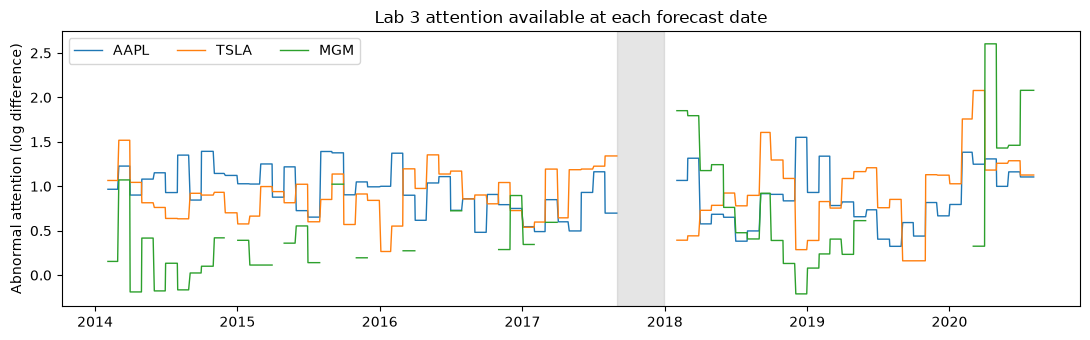

In [21]:
attention = pd.read_csv(LAB_DIR / "Data_PCLab4_Attention_Monthly.csv")
attention["Attention_Date"] = pd.to_datetime(
    attention["formation_ts"], utc=True
).dt.tz_convert("America/New_York").dt.tz_localize(None).dt.normalize()
attention["Attention"] = np.log1p(attention["att_window"]) - np.log1p(attention["att_baseline"])
assert np.allclose(attention["Attention"], attention["g"])
assert not attention.duplicated(["ticker", "Attention_Date"]).any()
assert set(attention["ticker"]) == set(model_stocks)
attention.loc[~attention["eligible"], "Attention"] = np.nan

attention_parts = []
for stock in model_stocks:
    left = enhanced_panel.loc[enhanced_panel["Stock"] == stock].sort_values("Date")
    right = attention.loc[attention["ticker"] == stock, ["Attention_Date", "Attention"]].sort_values("Attention_Date")
    joined = pd.merge_asof(left, right, left_on="Date", right_on="Attention_Date",
                           direction="backward", allow_exact_matches=False,
                           tolerance=pd.Timedelta(days=35))
    joined.loc[joined["Date"].between("2017-09-01", "2017-12-31"), "Attention"] = np.nan
    attention_parts.append(joined)
attention_panel = pd.concat(attention_parts, ignore_index=True)
available = attention_panel["Attention"].notna()
assert (attention_panel.loc[available, "Attention_Date"] < attention_panel.loc[available, "Date"]).all()
assert not attention_panel.loc[attention_panel["Date"].between("2017-09-01", "2017-12-31"), "Attention"].notna().any()

attention_rows, coverage_rows = [], []
for h in forecast_horizons:
    target = f"Future_Return_{h}d"
    columns = selected_features[h]
    frame = attention_panel.dropna(subset=columns + ["Attention", target, f"Target_Date_{h}d"])
    fit, valid, train, test = chronological_split(frame, h)
    coverage_rows.append({"Horizon": h, "Train rows": len(train), "Test rows": len(test),
                         "Train dates": train["Date"].nunique(), "Test dates": test["Date"].nunique(),
                         "Test coverage (%)": 100 * len(test) / len(test_data[h])})
    for label, predictors in {"OLS, matched sample": columns,
                              "OLS + attention": columns + ["Attention"]}.items():
        model = make_pipeline(MinMaxScaler(), LinearRegression())
        model.fit(fit[predictors], fit[target])
        valid_loss = mean_squared_error(valid[target], model.predict(valid[predictors]))
        model.fit(train[predictors], train[target])
        attention_rows.append({"Horizon": h, "Model": label, "Validation MSE": valid_loss,
                               **score_forecast(test[target], model.predict(test[predictors]))})
attention_results = pd.DataFrame(attention_rows)
display(pd.DataFrame(coverage_rows).round(2))
display(attention_results.round(3))

attention_gain = attention_results.pivot(index="Horizon", columns="Model", values="R2_OOS (%)")
attention_gain["Change (percentage points)"] = attention_gain["OLS + attention"] - attention_gain["OLS, matched sample"]
display(attention_gain.round(3))

fig, ax = plt.subplots(figsize=(11, 3.5))
for stock in ["AAPL", "TSLA", "MGM"]:
    values = attention_panel.loc[attention_panel["Stock"] == stock]
    ax.plot(values["Date"], values["Attention"], label=stock, linewidth=1)
ax.axvspan(pd.Timestamp("2017-09-01"), pd.Timestamp("2017-12-31"), color="grey", alpha=0.2)
ax.set(title="Lab 3 attention available at each forecast date", ylabel="Abnormal attention (log difference)")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()


**Findings.** Adding attention changes test $R^2_{OOS}$ from **1.02% to 1.09% (5d)**, **1.47% to 1.83% (20d)** and **4.00% to 5.41% (60d)**. These are gains of 0.07, 0.35 and 1.42 percentage points relative to OLS refitted on exactly the same rows, not relative to the full-sample baseline. Test coverage is about **95%**, with 3,652 observations at 60 days. Validation MSE improves slightly at 5/20 days but worsens from **146.21 to 154.34** at 60 days. Thus, the requested 60-day extension is feasible and improves this test result, but it would not have been selected at that horizon using validation alone.

The signal is feasible to include, but its shorter history and missing stock-months reduce coverage. It also inherits Lab 3's measurement choices: unique-user counts over a long window are scaled into a monthly baseline, which is a proxy rather than a literal average of monthly unique users. Attention remains a separate extension; Tasks 3–4 use the full price/volume sample so all eight stocks can be ranked every rebalance date.


## Task 3 - Nonlinear models: Random Forest and boosted trees

### Major Findings
- **Random Forest has the highest test $R^2_{OOS}$ at 5 and 20 days:** 0.84% and 3.54%, versus OLS at 0.54% and 0.69%.
- **Boosted trees lead at 60 days:** 10.82%, compared with Random Forest at 9.28% and OLS at 1.85%.
- Validation chooses boosted trees over Random Forest at all horizons; it chooses Ridge over both trees at 20/60 days. We keep these decisions fixed when evaluating the test set.

### 3.1 Why these models and how we train them

A **Random Forest** averages trees fitted to bootstrap samples and random subsets of features. **Gradient boosting** adds small trees to correct earlier prediction errors. Both can learn thresholds and interactions, such as momentum behaving differently when volatility is high. This follows the lecture's motivation for nonlinear models and is practical for our small dataset.

We use the same validation-selected features and exact train/test rows as the extended OLS and Ridge models. We compare depths 2 and 3 for the forest and depths 1 and 2 for boosting, with large minimum leaf sizes to limit overfitting. Settings are chosen by validation MSE; the seed is fixed. Models are fitted once before the test period, with no test-period retraining. This is a small, transparent search rather than an exhaustive optimization.


,Horizon,Model,Setting,Validation MSE
0,5,Random Forest,"depth=2, leaf=100",13.301
1,5,Random Forest,"depth=3, leaf=100",13.319
2,5,Boosted trees,"depth=1, leaf=100",13.236
3,5,Boosted trees,"depth=2, leaf=100",13.293
4,20,Random Forest,"depth=2, leaf=100",47.267
5,20,Random Forest,"depth=3, leaf=100",47.479
6,20,Boosted trees,"depth=1, leaf=100",46.631
7,20,Boosted trees,"depth=2, leaf=100",47.943
8,60,Random Forest,"depth=2, leaf=100",142.873
9,60,Random Forest,"depth=3, leaf=100",144.853


,Horizon,Model,Features,Setting,Validation MSE,R2_OOS (%),Test R2 (%),RMSE (pp),Correct sign (%)
7,5,Boosted trees,Original,"depth=1, leaf=100",13.236,0.438,-0.015,7.122,56.262
6,5,Random Forest,Original,"depth=2, leaf=100",13.301,0.838,0.387,7.108,56.262
1,5,Ridge,Original,alpha=100.0,13.305,0.449,-0.004,7.122,56.495
0,5,OLS,Original,Original,13.416,0.536,0.084,7.119,55.117
3,20,Ridge,Original,alpha=100.0,46.516,1.319,-0.408,13.995,57.764
9,20,Boosted trees,Original,"depth=1, leaf=100",46.631,2.102,0.389,13.939,58.077
2,20,OLS,Original,Original,47.169,0.694,-1.044,14.039,57.188
8,20,Random Forest,Original,"depth=2, leaf=100",47.267,3.542,1.854,13.836,58.077
5,60,Ridge,Original,alpha=1.0,134.984,1.719,-1.492,25.946,56.380
4,60,OLS,Original,Original,135.022,1.849,-1.357,25.928,56.589


,Horizon,Selected features,Best model on validation,Tree used in Task 4
0,5,Original,Boosted trees,Boosted trees
1,20,Original,Ridge,Boosted trees
2,60,Original,Ridge,Boosted trees


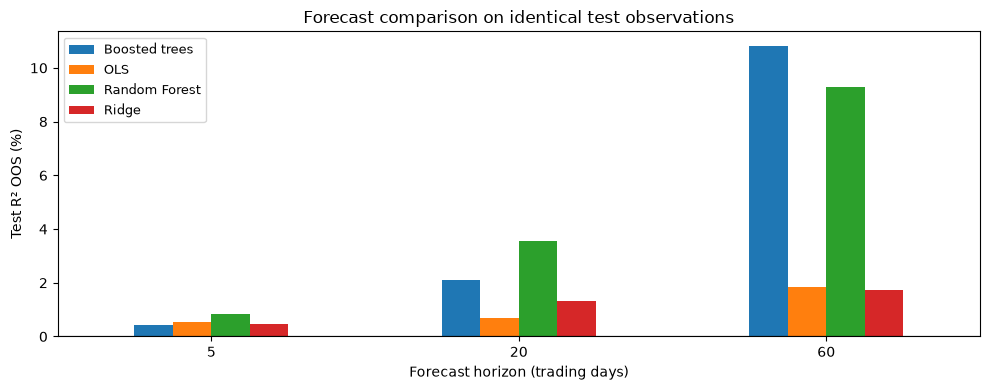

In [22]:
tree_tuning_rows = []
for h in forecast_horizons:
    target = f"Future_Return_{h}d"
    columns = selected_features[h]
    fit, valid, train, test = chronological_split(extended_dfs[h], h)
    tree_candidates = {
        "Random Forest": [
            (f"depth={depth}, leaf=100", RandomForestRegressor(
                n_estimators=150, max_depth=depth, min_samples_leaf=100,
                max_features=0.8, random_state=RANDOM_SEED, n_jobs=1))
            for depth in [2, 3]
        ],
        "Boosted trees": [
            (f"depth={depth}, leaf=100", GradientBoostingRegressor(
                n_estimators=100, learning_rate=0.03, max_depth=depth,
                min_samples_leaf=100, random_state=RANDOM_SEED))
            for depth in [1, 2]
        ]
    }
    for label, candidates in tree_candidates.items():
        trials = []
        for setting, estimator in candidates:
            estimator.fit(fit[columns], fit[target])
            loss = mean_squared_error(valid[target], estimator.predict(valid[columns]))
            trials.append((loss, setting, estimator))
            tree_tuning_rows.append({"Horizon": h, "Model": label, "Setting": setting,
                                     "Validation MSE": loss})
        loss, setting, model = min(trials, key=lambda item: item[0])
        model.fit(train[columns], train[target])
        prediction = model.predict(test[columns])
        fitted_models[h][label], test_predictions[h][label] = model, prediction
        validation_scores[h][label], model_settings[h][label] = loss, setting
        model_rows.append({"Horizon": h, "Model": label, "Features": selected_feature_names[h],
                           "Setting": setting, "Validation MSE": loss,
                           **score_forecast(test[target], prediction)})

model_results = pd.DataFrame(model_rows).sort_values(["Horizon", "Validation MSE"])
display(pd.DataFrame(tree_tuning_rows).round(3))
display(model_results.round(3))

selected_tree = {h: min(["Random Forest", "Boosted trees"], key=lambda name: validation_scores[h][name])
                 for h in forecast_horizons}
selection = pd.DataFrame([{
    "Horizon": h, "Selected features": selected_feature_names[h],
    "Best model on validation": min(validation_scores[h], key=validation_scores[h].get),
    "Tree used in Task 4": selected_tree[h]
} for h in forecast_horizons])
display(selection)

fig, ax = plt.subplots(figsize=(10, 4))
model_results.pivot(index="Horizon", columns="Model", values="R2_OOS (%)").plot.bar(ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(xlabel="Forecast horizon (trading days)", ylabel="Test R² OOS (%)",
       title="Forecast comparison on identical test observations")
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### 3.2 Interpreting performance and relating it to the papers

The longer-horizon tree forecasts beat both OLS and the training-mean benchmark in squared error, consistent with the idea that nonlinear price/volume relationships can help. The result is strongest at 60 days. However, both tree models' direction accuracies (**56.26%, 58.08%, 58.57%**) equal the always-positive benchmark, so these percentages do not demonstrate useful up/down timing. The best model in hindsight also differs from the validation winner; test results are an evaluation, not a new model-selection step.

**Gu, Kelly and Xiu (2020).** Their gains from trees and neural networks motivate our nonlinear models, and we use their equation (19) for $R^2_{OOS}$. However, they study monthly **excess returns**, a broad US stock universe, many firm characteristics and macroeconomic interactions, over decades. We study eight stocks, raw price returns, a few technical signals and overlapping daily forecast origins. Our scores therefore cannot be compared numerically with their results, and a different model ranking would not contradict their paper.

**Jiang, Kelly and Xiu (2023).** They feed images of open/high/low/close prices, moving averages and volume into a CNN to predict the **probability of a positive return**. We share the 5/20/60-day horizons and price/volume motivation, but use numerical summary features and predict return magnitudes. Our files contain one price series per stock, not full OHLC data. The moving-average feature borrows a useful idea; this is not a CNN replication. Predicting directions or ranking stocks can help a portfolio even when aggregate squared-error performance is weak.

Sources: *FBD_Week5_Lecture4_2026.pdf*, lecture slides 54–63; Gu et al., *Empirical Asset Pricing via Machine Learning*, sections 1.1, 1.6 and equation (19); Jiang et al., *(Re-)Imag(in)ing Price Trends*, introduction and section I.


## Task 4 - Performance of the AI-driven portfolio

### Major Findings
- After the slide's fees, $100 becomes **$154.65 (5d), $164.10 (20d), and $226.72 (60d)** over 20 June 2018–11 August 2020.
- The net strategies beat **54.6%, 66.0% and 96.0%** of the 1,000 random net buy-and-hold portfolios.
- Fees at 1 bp have little effect, but drawdowns are substantial. The gross OLS top-four portfolios outperform the corresponding tree portfolios at every horizon.

### 4.1 Portfolio construction and trading costs

We start with **$100**, rank all eight stocks by predicted return, and put 25% in each of the top four. We rebalance every **h trading days** for the h-day forecast, holding fixed share quantities in between. We use the better of the two tree models **on validation**, even if OLS later performs better on the test. We also run the OLS top-four rule as a reference. The 20-day strategy is the central example; all three horizons are reported, without selecting a horizon from realized profits.

All strategies share the original test start and the final price date. Features allow forecasts even near the sample end, when a full h-day target cannot be evaluated; the final holding interval is shortened and liquidated on the last date. Trades assume fractional shares and execution at the forecast close, after observing that close's price and volume. This is a stylized close-to-close backtest; actual execution delays, spreads and slippage are not modeled. Negative forecasts still result in four long positions, as required by the assignment.

**Fees.** We follow the slide's example: replacing $50 of A with B costs **$0.005 in total**. At a rebalance, charged turnover is half the sum of absolute weight changes, using the weights **after they drift with prices**. Entry and final liquidation each incur 1 bp on the full portfolio. Fees are deducted from wealth before setting new holdings. We also report a stricter sensitivity charging 1 bp on each buy and sell leg (twice the rebalance turnover); this would charge $0.01 for the slide's $50 switch.


In [23]:
test_prices = price_df.set_index("Date").loc[split_date:, model_stocks]
portfolio_dates = test_prices.index
assert test_prices.notna().all().all()
portfolio_predictions = {}

for h in forecast_horizons:
    forecast_frame = enhanced_panel.loc[enhanced_panel["Date"] >= split_date].copy()
    for label in [selected_tree[h], "OLS"]:
        prediction = fitted_models[h][label].predict(forecast_frame[selected_features[h]])
        wide = forecast_frame.assign(Prediction=prediction).pivot(
            index="Date", columns="Stock", values="Prediction"
        ).reindex(index=portfolio_dates, columns=model_stocks)
        assert np.isfinite(wide).all().all()
        portfolio_predictions[h, label] = wide

def backtest_top_four(predictions, horizon, fee_rate=0.0, per_leg=False):
    """Fixed shares between rebalances; mark wealth at every daily close."""
    prices = test_prices.to_numpy()
    wealth = INITIAL_WEALTH
    shares = np.zeros(len(model_stocks))
    path, trades = [], []
    for day, date in enumerate(portfolio_dates):
        if day > 0:
            wealth = float(shares @ prices[day])
        if day % horizon == 0 and day < len(prices) - 1:
            # Stable sorting makes ties deterministic, using the CSV ticker order.
            ranks = np.argsort(-predictions.iloc[day].to_numpy(), kind="stable")[:4]
            weights = np.zeros(len(model_stocks))
            weights[ranks] = 0.25
            old_weights = shares * prices[day] / wealth
            turnover = 1.0 if day == 0 else np.abs(weights - old_weights).sum() / 2
            charged_turnover = turnover * (2 if per_leg and day > 0 else 1)
            fee = wealth * fee_rate * charged_turnover
            wealth -= fee
            shares = wealth * weights / prices[day]
            assert np.isclose(shares @ prices[day], wealth)
            assert np.count_nonzero(shares) == 4
            trades.append({"Date": date, "Holdings": ", ".join(np.array(model_stocks)[ranks]),
                           "Turnover": turnover, "Fee ($)": fee})
        if day == len(prices) - 1:
            fee = wealth * fee_rate
            wealth -= fee
            trades.append({"Date": date, "Holdings": "Liquidation", "Turnover": 1.0, "Fee ($)": fee})
        path.append(wealth)
    return pd.Series(path, index=portfolio_dates), pd.DataFrame(trades)

def describe_wealth(path):
    # Include entry costs in both total performance and drawdown.
    values = np.r_[INITIAL_WEALTH, path.to_numpy()]
    daily_returns = pd.Series(values[1:] / values[:-1] - 1)
    running_max = np.maximum.accumulate(values)
    years = (path.index[-1] - path.index[0]).days / 365.25
    return {"Final wealth ($)": path.iloc[-1],
            "Total return (%)": 100 * (path.iloc[-1] / INITIAL_WEALTH - 1),
            "CAGR (%)": 100 * ((path.iloc[-1] / INITIAL_WEALTH) ** (1 / years) - 1),
            "Annual volatility (%)": 100 * daily_returns.std() * np.sqrt(252),
            "Max drawdown (%)": 100 * (values / running_max - 1).min()}

portfolio_paths, portfolio_trades, portfolio_rows = {}, {}, []
for h in forecast_horizons:
    for label, predictor, fee, per_leg in [
        ("AI gross", selected_tree[h], 0.0, False),
        ("AI net (slide fees)", selected_tree[h], FEE_RATE, False),
        ("AI net (per-leg fees)", selected_tree[h], FEE_RATE, True),
        ("OLS gross", "OLS", 0.0, False)
    ]:
        path, trades = backtest_top_four(portfolio_predictions[h, predictor], h, fee, per_leg)
        portfolio_paths[h, label], portfolio_trades[h, label] = path, trades
        portfolio_rows.append({"Horizon": h, "Strategy": label, "Model": predictor,
                               **describe_wealth(path), "Fees paid ($)": trades["Fee ($)"].sum(),
                               "Entry/rebalances": len(trades) - 1})
    assert (portfolio_paths[h, "AI net (slide fees)"] <= portfolio_paths[h, "AI gross"] + 1e-8).all()
    assert (portfolio_paths[h, "AI net (per-leg fees)"] <= portfolio_paths[h, "AI net (slide fees)"] + 1e-8).all()

# Reconstruct gross terminal wealth from non-overlapping holding-period returns.
for h in forecast_horizons:
    prediction = portfolio_predictions[h, selected_tree[h]]
    reconstructed = INITIAL_WEALTH
    for start in range(0, len(test_prices) - 1, h):
        end = min(start + h, len(test_prices) - 1)
        chosen = np.argsort(-prediction.iloc[start].to_numpy(), kind="stable")[:4]
        relatives = test_prices.iloc[end].to_numpy() / test_prices.iloc[start].to_numpy()
        reconstructed *= relatives[chosen].mean()
    assert np.isclose(reconstructed, portfolio_paths[h, "AI gross"].iloc[-1])

portfolio_results = pd.DataFrame(portfolio_rows)
print(f"Common test period: {portfolio_dates[0].date()} to {portfolio_dates[-1].date()}")
display(portfolio_results.round(3))
display(portfolio_trades[20, "AI net (slide fees)"].head(8).round({"Turnover": 4, "Fee ($)": 4}))


Common test period: 2018-06-20 to 2020-08-11


,Horizon,Strategy,Model,Final wealth ($),Total return (%),CAGR (%),Annual volatility (%),Max drawdown (%),Fees paid ($),Entry/rebalances
0,5,AI gross,Boosted trees,155.062,55.062,22.706,42.718,-59.601,0.000,108
1,5,AI net (slide fees),Boosted trees,154.647,54.647,22.553,42.718,-59.605,0.310,108
2,5,AI net (per-leg fees),Boosted trees,154.265,54.265,22.411,42.718,-59.609,0.593,108
3,5,OLS gross,OLS,198.141,98.141,37.572,38.428,-54.243,0.000,108
4,20,AI gross,Boosted trees,164.236,64.236,26.041,40.344,-45.192,0.000,27
5,20,AI net (slide fees),Boosted trees,164.103,64.103,25.993,40.345,-45.196,0.092,27
6,20,AI net (per-leg fees),Boosted trees,164.004,64.004,25.957,40.345,-45.200,0.157,27
7,20,OLS gross,OLS,166.024,66.024,26.679,31.828,-34.370,0.000,27
8,60,AI gross,Boosted trees,226.837,126.837,46.532,36.532,-43.809,0.000,9
9,60,AI net (slide fees),Boosted trees,226.722,126.722,46.497,36.532,-43.812,0.072,9


,Date,Holdings,Turnover,Fee ($)
0,2018-06-20,"TSLA, AAPL, BA, T",1.0000,0.0100
1,2018-07-19,"AAPL, BA, T, MGM",0.2512,0.0025
2,2018-08-16,"AAPL, BA, T, MGM",0.0343,0.0003
3,2018-09-14,"TSLA, AAPL, BA, T",0.2513,0.0026
4,2018-10-12,"TSLA, MGM, AAPL, BA",0.2711,0.0026
5,2018-11-09,"TSLA, IBM, AAPL, BA",0.2938,0.0031
6,2018-12-11,"AAPL, IBM, AMZN, BA",0.2941,0.0028
7,2019-01-10,"AAPL, IBM, BA, MGM",0.2733,0.0027


### 4.2 Comparison with 1,000 random buy-and-hold portfolios

We draw nonnegative initial weights from a **Dirichlet(1,…,1)** distribution, which is uniform over the eight-stock weight simplex, and invest $100. Each portfolio buys once and holds the same shares to the end: weights drift, and there is no daily rebalancing. The fixed seed makes this comparison reproducible. Equal-weight buy-and-hold and the S&P 500 price index are additional benchmarks. Random portfolios hold eight stocks, whereas the AI portfolio holds four, so diversification differs.

We compare gross with gross and net with net. Random net portfolios pay only the initial and final 1 bp fees. A percentile describes performance within these random allocations on this one historical price path; it is **not a statistical p-value** or evidence that the strategy will repeat its performance.


,Benchmark,Final wealth ($),Total return (%),CAGR (%),Annual volatility (%),Max drawdown (%)
0,Equal-weight buy-and-hold,152.849,52.849,21.886,31.339,-41.482
1,S&P 500 price index,120.466,20.466,9.074,25.402,-33.925


,Statistic,Random gross final ($),Random net final ($)
0,Minimum,82.01,82.00
1,5th percentile,103.61,103.59
2,Median,150.31,150.28
3,95th percentile,222.73,222.68
4,Maximum,292.20,292.14


,Horizon,AI gross final ($),AI net final ($),Gross percentile,Net percentile
0,5,155.06,154.65,55.1,54.6
1,20,164.24,164.10,66.1,66.0
2,60,226.84,226.72,96.0,96.0


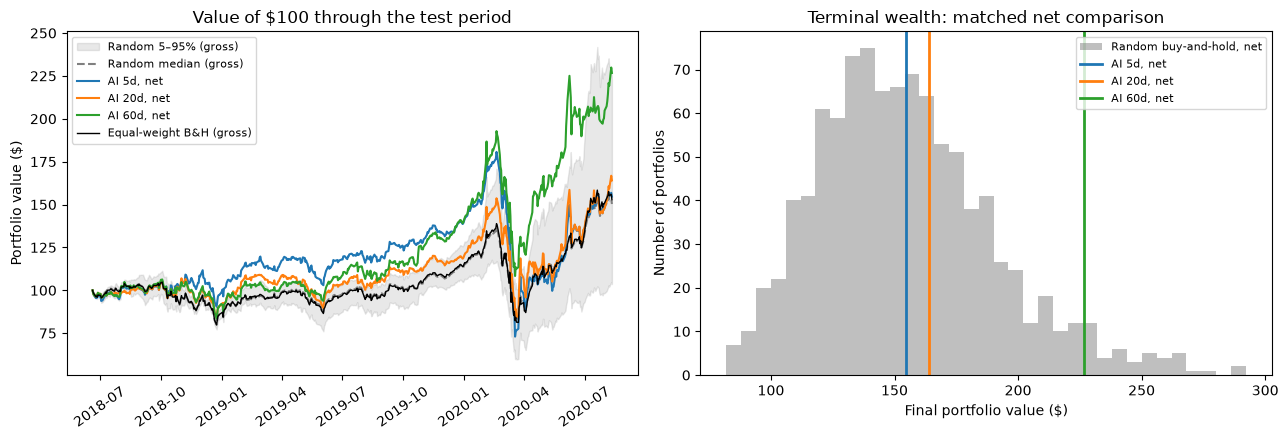

In [24]:
rng = np.random.default_rng(RANDOM_SEED)
random_weights = rng.dirichlet(np.ones(len(model_stocks)), size=N_RANDOM_PORTFOLIOS)
assert (random_weights >= 0).all() and np.allclose(random_weights.sum(axis=1), 1)
price_relatives = test_prices / test_prices.iloc[0]
random_paths = INITIAL_WEALTH * price_relatives.to_numpy() @ random_weights.T
assert np.allclose(random_paths[0], INITIAL_WEALTH)
random_terminal = random_paths[-1]
random_net_terminal = random_terminal * (1 - FEE_RATE) ** 2
equal_weight_path = INITIAL_WEALTH * price_relatives.mean(axis=1)
market_prices = price_df.set_index("Date").loc[portfolio_dates, "sp500"]
market_path = INITIAL_WEALTH * market_prices / market_prices.iloc[0]

benchmark_rows = [
    {"Benchmark": "Equal-weight buy-and-hold", **describe_wealth(equal_weight_path)},
    {"Benchmark": "S&P 500 price index", **describe_wealth(market_path)}
]
display(pd.DataFrame(benchmark_rows).round(3))
display(pd.DataFrame({"Statistic": ["Minimum", "5th percentile", "Median", "95th percentile", "Maximum"],
                      "Random gross final ($)": np.quantile(random_terminal, [0, .05, .5, .95, 1]),
                      "Random net final ($)": np.quantile(random_net_terminal, [0, .05, .5, .95, 1])}).round(2))

percentile_rows = []
for h in forecast_horizons:
    gross = portfolio_paths[h, "AI gross"].iloc[-1]
    net = portfolio_paths[h, "AI net (slide fees)"].iloc[-1]
    percentile_rows.append({"Horizon": h, "AI gross final ($)": gross, "AI net final ($)": net,
                           "Gross percentile": 100 * np.mean(random_terminal < gross),
                           "Net percentile": 100 * np.mean(random_net_terminal < net)})
portfolio_percentiles = pd.DataFrame(percentile_rows)
display(portfolio_percentiles.round(2))

horizon_colors = {5: "tab:blue", 20: "tab:orange", 60: "tab:green"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
lower, median, upper = np.quantile(random_paths, [0.05, 0.5, 0.95], axis=1)
axes[0].fill_between(portfolio_dates, lower, upper, alpha=0.18, color="grey", label="Random 5–95% (gross)")
axes[0].plot(portfolio_dates, median, color="grey", linestyle="--", label="Random median (gross)")
for h in forecast_horizons:
    axes[0].plot(portfolio_dates, portfolio_paths[h, "AI net (slide fees)"], label=f"AI {h}d, net", color=horizon_colors[h])
axes[0].plot(portfolio_dates, equal_weight_path, color="black", linewidth=1, label="Equal-weight B&H (gross)")
axes[0].set(title="Value of $100 through the test period", ylabel="Portfolio value ($)")
axes[0].legend(fontsize=8)
axes[1].hist(random_net_terminal, bins=35, color="grey", alpha=0.5, label="Random buy-and-hold, net")
for h in forecast_horizons:
    axes[1].axvline(portfolio_paths[h, "AI net (slide fees)"].iloc[-1], label=f"AI {h}d, net", linewidth=2, color=horizon_colors[h])
axes[1].set(title="Terminal wealth: matched net comparison", xlabel="Final portfolio value ($)", ylabel="Number of portfolios")
axes[1].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


### 4.3 What we can conclude

The 20-day strategy finishes at **$164.24 before fees and $164.10 after fees**, versus **$152.85** for equal-weight buy-and-hold and **$120.47** for the S&P 500 price index before fees. The random gross median is **$150.31**, with a 5th–95th percentile range of **$103.61–$222.73**. Our 20-day net strategy is at the **66th percentile**, a moderate result rather than exceptional evidence of skill.

The 60-day tree strategy earns the most among the three tree portfolios, finishing at **$226.72 net**, but its maximum drawdown is **43.81%**. Drawdowns are **59.61%** and **45.20%** for the 5- and 20-day strategies. The gross OLS strategies finish at **$198.14, $166.02 and $227.78** respectively, showing that better aggregate return forecasts need not give better top-four rankings. For 20 days, stricter per-leg fees reduce final wealth to **$164.00**; costs at this assumed rate do not change the main conclusion. The terminal gross/net difference includes both fees paid and the return forgone on those fees.

The portfolio only needs to rank the stocks well; it does not need perfectly calibrated return forecasts. Nonetheless, high terminal wealth alone does not establish skill: the eight-stock universe contains strong winners, random buy-and-hold portfolios differ widely, and the AI rule is concentrated. These results use supplied price changes, with no verified dividend adjustment, and exclude spreads, slippage, taxes and financing costs. The test includes the 2020 market shock and is only one historical period. Monthly attention coverage, overlapping targets and the small stock universe further limit generalization.

**Reproducibility.** Run from the repository root or `#4` with pandas, NumPy, matplotlib, scikit-learn and statsmodels. All inputs are local CSVs, including the compact attention extract; no download or NLP inference is required. Models use seed 42. Report your group's actual time spent before submission, as requested in the assignment.
